In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import normflows as nf

import time
from torch.distributions import Normal

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class NBase(nn.Module):
    def __init__(self, dim, init_loc=0.0, init_log_scale=-2.5):
        super().__init__()
        self.dim = dim
        self.loc = nn.Parameter(torch.full((dim,), float(init_loc)))
        self.raw_log_scale = nn.Parameter(torch.full((dim,), float(init_log_scale)))

    def log_scale(self):
        return torch.clamp(self.raw_log_scale, min=-5.0, max=2.0)

    def scale(self):
        return torch.exp(self.log_scale())

    def rsample(self, num_samples):
        eta = torch.randn(
            num_samples,
            self.dim,
            device=self.loc.device,
            dtype=self.loc.dtype,
        )
        z0 = self.loc.unsqueeze(0) + self.scale().unsqueeze(0) * eta
        return eta, z0

    def log_prob(self, z0):
        log_scale = self.log_scale().unsqueeze(0)
        var = torch.exp(2.0 * log_scale)
        return -0.5 * (
            ((z0 - self.loc.unsqueeze(0)) ** 2) / var
            + 2.0 * log_scale
            + math.log(2.0 * math.pi)
        ).sum(dim=1)

In [3]:
def simfun1(n=180, p=100, seed=123, snr=3.0, true_prop=0.1, device=None, dtype=torch.float32,):

    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    X = rng.standard_normal((n, p)).astype(np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-8)

    n_active = int(p * true_prop)
    active_idx = np.sort(rng.choice(p, size=n_active, replace=False))

    beta_true = np.zeros(p, dtype=np.float32)
    magnitudes = rng.uniform(0.3, 2.0, size=n_active).astype(np.float32)
    signs = rng.choice([-1.0, 1.0], size=n_active).astype(np.float32)
    beta_true[active_idx] = signs * magnitudes

    signal = X @ beta_true
    sigma2 = np.var(signal) / snr
    sigma = np.sqrt(sigma2)

    y = signal + sigma * rng.standard_normal(n).astype(np.float32)
    y = y - y.mean()

    X_t = torch.tensor(X, dtype=dtype, device=device)
    y_t = torch.tensor(y, dtype=dtype, device=device)
    beta_true_t = torch.tensor(beta_true, dtype=dtype, device=device)

    info = {"n": n, "p": p, "n_active": n_active, "sigma2": float(sigma2), "sigma": float(sigma), "active_idx": active_idx, "snr": snr,}

    return X_t, y_t, beta_true_t, info

In [4]:
class SemanticAffineCoupling(nn.Module):
    """
    Affine coupling layer on semantic blocks of xi = [s, u, t].

    Mode:
        - "s": update s conditioned on (u, t)
        - "u": update u conditioned on (s, t)
        - "t": update t conditioned on (s, u)

    xi shape: [batch, 2p + 1]
    ordering : [ s(0:p) | u(p:2p) | t(2p) ]
    """
    def __init__(self, p, mode, hidden_units=128, num_hidden_layers=2, scale_clip=2.0):
        super().__init__()
        assert mode in {"s", "u", "t"}
        self.p = int(p)
        self.dim = 2 * p + 1
        self.mode = mode
        self.scale_clip = float(scale_clip)

        if mode == "s":
            cond_dim = p + 1      # (u, t)
            trans_dim = p         # s
        elif mode == "u":
            cond_dim = p + 1      # (s, t)
            trans_dim = p         # u
        else:  # mode == "t"
            cond_dim = 2 * p      # (s, u)
            trans_dim = 1         # t

        widths = [cond_dim] + [hidden_units] * num_hidden_layers + [2 * trans_dim]
        self.net = nf.nets.MLP(widths, init_zeros=True)

    def _split(self, x):
        s = x[:, :self.p]
        u = x[:, self.p:2 * self.p]
        t = x[:, 2 * self.p:2 * self.p + 1]
        return s, u, t

    def _merge(self, s, u, t):
        return torch.cat([s, u, t], dim=-1)

    def _affine_params(self, cond):
        h = self.net(cond)
        log_scale, shift = torch.chunk(h, 2, dim=-1)
        log_scale = self.scale_clip * torch.tanh(log_scale / self.scale_clip)
        return log_scale, shift

    def forward(self, x, return_logdet=False):
        s, u, t = self._split(x)

        if self.mode == "s":
            cond = torch.cat([u, t], dim=-1)
            log_scale, shift = self._affine_params(cond)
            s_new = s * torch.exp(log_scale) + shift
            y = self._merge(s_new, u, t)
            logdet = log_scale.sum(dim=-1)

        elif self.mode == "u":
            cond = torch.cat([s, t], dim=-1)
            log_scale, shift = self._affine_params(cond)
            u_new = u * torch.exp(log_scale) + shift
            y = self._merge(s, u_new, t)
            logdet = log_scale.sum(dim=-1)

        else:  # mode == "t"
            cond = torch.cat([s, u], dim=-1)
            log_scale, shift = self._affine_params(cond)
            t_new = t * torch.exp(log_scale) + shift
            y = self._merge(s, u, t_new)
            logdet = log_scale.sum(dim=-1)

        if return_logdet:
            return y, logdet
        return y

    def inverse(self, y, return_logdet=False):
        s, u, t = self._split(y)

        if self.mode == "s":
            cond = torch.cat([u, t], dim=-1)
            log_scale, shift = self._affine_params(cond)
            s_old = (s - shift) * torch.exp(-log_scale)
            x = self._merge(s_old, u, t)
            logdet = (-log_scale).sum(dim=-1)

        elif self.mode == "u":
            cond = torch.cat([s, t], dim=-1)
            log_scale, shift = self._affine_params(cond)
            u_old = (u - shift) * torch.exp(-log_scale)
            x = self._merge(s, u_old, t)
            logdet = (-log_scale).sum(dim=-1)

        else:  # mode == "t"
            cond = torch.cat([s, u], dim=-1)
            log_scale, shift = self._affine_params(cond)
            t_old = (t - shift) * torch.exp(-log_scale)
            x = self._merge(s, u, t_old)
            logdet = (-log_scale).sum(dim=-1)

        if return_logdet:
            return x, logdet
        return x


class FlowMap(nn.Module):
    def __init__(self, p=None, dim=None, K=4,
                 hidden_units=128, num_hidden_layers=2, scale_clip=2.0):
        super().__init__()

        if p is None:
            if dim is None:
                raise ValueError("Either p or dim must be provided.")
            if (dim - 1) % 2 != 0:
                raise ValueError("dim must equal 2*p + 1.")
            p = (dim - 1) // 2

        self.p = int(p)
        self.dim = 2 * self.p + 1

        layers = []
        for _ in range(K):
            layers.append(
                SemanticAffineCoupling(
                    p=self.p, mode="s",
                    hidden_units=hidden_units,
                    num_hidden_layers=num_hidden_layers,
                    scale_clip=scale_clip,
                )
            )
            layers.append(
                SemanticAffineCoupling(
                    p=self.p, mode="u",
                    hidden_units=hidden_units,
                    num_hidden_layers=num_hidden_layers,
                    scale_clip=scale_clip,
                )
            )
            layers.append(
                SemanticAffineCoupling(
                    p=self.p, mode="t",
                    hidden_units=hidden_units,
                    num_hidden_layers=num_hidden_layers,
                    scale_clip=scale_clip,
                )
            )

        self.layers = nn.ModuleList(layers)

    def forward(self, x, return_logdet=False):
        z = x
        if return_logdet:
            total_logdet = x.new_zeros(x.shape[0])

        for layer in self.layers:
            if return_logdet:
                z, logdet = layer(z, return_logdet=True)
                total_logdet = total_logdet + logdet
            else:
                z = layer(z)

        if return_logdet:
            return z, total_logdet
        return z

    def inverse(self, z, return_logdet=False):
        x = z
        if return_logdet:
            total_logdet = z.new_zeros(z.shape[0])

        for layer in reversed(self.layers):
            if return_logdet:
                x, logdet = layer.inverse(x, return_logdet=True)
                total_logdet = total_logdet + logdet
            else:
                x = layer.inverse(x)

        if return_logdet:
            return x, total_logdet
        return x

In [5]:
class Relaxedsas(nn.Module):
    def __init__(
        self,
        X,
        y,
        sigma2,
        tau,
        g_theta,
        penalty_type="none",
        support_target=None,
    ):
        super().__init__()
        if g_theta is None:
            raise ValueError("g_theta must be provided.")

        self.register_buffer("X", X)
        self.register_buffer("y", y)
        self.register_buffer("sigma2", torch.tensor(float(sigma2), dtype=X.dtype, device=X.device))
        self.register_buffer("tau", torch.tensor(float(tau), dtype=X.dtype, device=X.device))

        self.n, self.p = X.shape
        self.dim = 2 * self.p + 1
        self.g_theta = g_theta

        self.penalty_type = penalty_type
        self.support_target = support_target

    def set_tau(self, tau):
        self.tau.fill_(float(tau))

    def decode(self, eps):
        xi = self.g_theta(eps)

        p = self.p
        s = xi[:, :p]
        u = xi[:, p:2 * p]
        t = xi[:, 2 * p:2 * p + 1]

        gate = torch.sigmoid((u - t) / self.tau)
        beta = s * gate

        return {
            "eps": eps,
            "xi": xi,
            "s": s,
            "u": u,
            "t": t,
            "gate": gate,
            "beta": beta,
        }

    def penalty(self, dec):
        gate = dec["gate"]                      # [B, p]
        soft_support = gate.sum(dim=1)         # [B]

        if self.penalty_type == "none":
            pen = torch.zeros_like(soft_support)

        elif self.penalty_type == "support_l1":
            pen = soft_support

        elif self.penalty_type == "support_target":
            if self.support_target is None:
                raise ValueError("support_target must be provided for support_target penalty.")
            target = torch.as_tensor(
                float(self.support_target),
                dtype=soft_support.dtype,
                device=soft_support.device,
            )
            pen = (soft_support - target).pow(2)

        else:
            raise ValueError(f"Unknown penalty_type: {self.penalty_type}")

        return pen

    def log_joint(self, eps):
        dec = self.decode(eps)
        beta = dec["beta"]

        fit = self.X @ beta.T
        resid = self.y[:, None] - fit

        loglik = -0.5 * (
            resid.pow(2).sum(dim=0) / self.sigma2
            + self.n * torch.log(2.0 * torch.pi * self.sigma2)
        )

        log_p0_eps = -0.5 * (
            eps.pow(2) + math.log(2.0 * math.pi)
        ).sum(dim=1)

        return loglik + log_p0_eps

In [6]:
class FlowVI(nn.Module):
    def __init__(self, q0, posterior_flow, generative_model):
        super().__init__()
        self.q0 = q0
        self.posterior_flow = posterior_flow
        self.generative_model = generative_model

    def sample_posterior(self, num_samples):
        _, z0 = self.q0.rsample(num_samples)
        eps, logdet = self.posterior_flow(z0, return_logdet=True)
        log_q_eps = self.q0.log_prob(z0) - logdet
        return eps, log_q_eps

    def neg_elbo(self, num_samples=256, elbo_beta=1.0, penalty_weight=0.0, return_parts=False):
        eps, log_q_eps = self.sample_posterior(num_samples)

        log_joint = self.generative_model.log_joint(eps)
        dec = self.generative_model.decode(eps)
        penalty = self.generative_model.penalty(dec)

        base_obj = (log_q_eps - elbo_beta * log_joint).mean()
        penalty_mean = penalty.mean()
        total = base_obj + penalty_weight * penalty_mean

        if return_parts:
            return {
                "loss": total,
                "base_obj": base_obj.detach(),
                "penalty": penalty_mean.detach(),
                "soft_support_mean": dec["gate"].sum(dim=1).mean().detach(),
            }

        return total


def build_flow_vi(
    X,
    y,
    sigma2,
    tau,
    K_q=8,
    K_g=8,
    hidden_units=64,
    num_hidden_layers=2,
    penalty_type="none",
    support_target=None,
):
    dim = 2 * X.shape[1] + 1

    g_theta = FlowMap(
        dim=dim,
        K=K_g,
        hidden_units=hidden_units,
        num_hidden_layers=num_hidden_layers,
        scale_clip=2.0,
    )

    generative_model = Relaxedsas(
        X=X,
        y=y,
        sigma2=sigma2,
        tau=tau,
        g_theta=g_theta,
        penalty_type=penalty_type,
        support_target=support_target,
    )

    q0 = NBase(dim=dim, init_loc=0.0, init_log_scale=-2.5)

    posterior_flow = FlowMap(
        dim=dim,
        K=K_q,
        hidden_units=hidden_units,
        num_hidden_layers=num_hidden_layers,
        scale_clip=2.0,
    )

    return FlowVI(q0=q0, posterior_flow=posterior_flow, generative_model=generative_model)

In [13]:
def train_flow(
    model,
    epochs=1000,
    num_samples=128,
    lr=5e-5,
    tau_start=1.0,
    tau_end=0.05,
    anneal_ratio=0.7,
    grad_clip=3.0,
    print_every=100,
    elbo_beta=1.0,
    pip_R=2000,
    penalty_weight=0.0,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    tau_hist = []
    grad_hist = []
    penalty_hist = []
    soft_support_hist = []
    expected_support_hist = []
    suspect_hist = []

    anneal_epochs = max(1, int(round(epochs * anneal_ratio)))

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        if epoch <= anneal_epochs:
            frac = (epoch - 1) / max(anneal_epochs - 1, 1)
            tau_now = tau_start * (tau_end / tau_start) ** frac
        else:
            tau_now = float(tau_end)

        model.generative_model.set_tau(tau_now)
        tau_hist.append(float(tau_now))

        out = model.neg_elbo(
            num_samples=num_samples,
            elbo_beta=elbo_beta,
            penalty_weight=penalty_weight,
            return_parts=True,
        )
        loss = out["loss"]
        loss.backward()

        if grad_clip is not None:
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            grad_norm = float(grad_norm)
        else:
            grad_norm = 0.0

        optimizer.step()

        losses.append(float(loss.item()))
        grad_hist.append(grad_norm)
        penalty_hist.append(float(out["penalty"].item()))
        soft_support_hist.append(float(out["soft_support_mean"].item()))

        draws = sample_posterior_latents(model, R=pip_R)
        u = draws["u"]
        t = draws["t"]
        if t.ndim == 1:
            t = t.unsqueeze(1)

        pip = (u > t).float().mean(dim=0)
        expected_support = float(pip.sum().item())
        suspect_num = int(((pip > 0.3) & (pip < 0.7)).sum().item())

        expected_support_hist.append(expected_support)
        suspect_hist.append(suspect_num)

        if epoch % print_every == 0 or epoch == 1:
            print(
                f"[epoch {epoch:04d}] "
                f"loss={loss.item():.6f} "
                f"tau={tau_now:.6f} "
                f"grad_norm={grad_norm:.6f} "
                f"penalty={out['penalty'].item():.6f} "
                f"soft_support={out['soft_support_mean'].item():.3f} "
                f"expected_select={expected_support:.3f} "
                f"suspect_number={suspect_num}"
            )

    return (
        losses,
        tau_hist,
        grad_hist,
        penalty_hist,
        soft_support_hist,
        expected_support_hist,
        suspect_hist,
    )

In [8]:
@torch.no_grad()
def sample_posterior_latents(model, R=2000):
    model.eval()

    q0 = model.q0
    _, z0 = q0.rsample(R)               # [R, d]
    eps, _ = model.posterior_flow(z0, return_logdet=True)
    dec = model.generative_model.decode(eps)

    out = {
        "s": dec["s"].detach().cpu(),          # [R, p]
        "u": dec["u"].detach().cpu(),          # [R, p]
        "t": dec["t"].detach().cpu(),          # [R, 1] or [R]
        "beta": dec["beta"].detach().cpu(),    # [R, p]
    }
    return out

@torch.no_grad()
def pip_summary(model, beta_true=None, R=2000, c=0.5):
    draws = sample_posterior_latents(model, R=R)

    s = draws["s"]
    u = draws["u"]                      # [R, p]
    t = draws["t"]
    beta = draws["beta"]

    if t.ndim == 1:
        t = t.unsqueeze(1)              # [R, 1]

    ind = (u > t).int()                 # [R, p]
    pip = ind.float().mean(dim=0)       # [p]
    beta_soft_mean = beta.mean(dim=0)        # [p]
    beta_hard_mean = (s * ind.float()).mean(dim=0)

    support_c = (pip > c).int().numpy()

    df = pd.DataFrame({
    "j": np.arange(pip.numel()),
    "pip": pip.numpy(),
    "beta_hard_mean": beta_hard_mean.numpy(),
    "beta_soft_mean": beta_soft_mean.numpy(),
    "selected_c": support_c,
})

    metrics = {
        "R": R,
        "pip_threshold": c,
        "expected_support_size": float(pip.sum().item()),
        "n_selected_at_c": int(support_c.sum()),
        "selected_idx_at_c": np.where(support_c == 1)[0].tolist(),
    }

    if beta_true is not None:
        beta_true_cpu = beta_true.detach().cpu()
        truth = (beta_true_cpu.abs() > 1e-12).int().numpy()
        pred = support_c

        tp = int(((pred == 1) & (truth == 1)).sum())
        fp = int(((pred == 1) & (truth == 0)).sum())
        fn = int(((pred == 0) & (truth == 1)).sum())
        tn = int(((pred == 0) & (truth == 0)).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        df["beta_true"] = beta_true_cpu.numpy()
        df["truth"] = truth
        df["pred_c"] = pred

        metrics.update({
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return df, metrics, draws

In [14]:
def simflow(
    seed=123,
    device=None,
    dtype=torch.float32,
    hidden_units=64,
    num_hidden_layers=2,
    anneal_ratio=1.0,
    n=180,
    p=100,
    snr=3.0,
    true_prop=0.1,
    tau_end=0.5,
    K_q=8,
    K_g=8,
    epochs=1000,
    num_samples=128,
    lr=5e-5,
    grad_clip=3.0,
    print_every=100,
    pip_R=2000,
    pip_c=0.5,
    penalty_type="none",
    penalty_weight=0.0,
    support_target=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X, y, beta_true, sim_info = simfun1(
        n=n,
        p=p,
        seed=seed,
        snr=snr,
        true_prop=true_prop,
        device=device,
        dtype=dtype,
    )

    print("===== Simulation info =====")
    print(sim_info)

    if penalty_type == "support_target" and support_target is None:
        support_target = int(round(true_prop * p))

    model = build_flow_vi(
        X=X,
        y=y,
        sigma2=sim_info["sigma2"],
        tau=tau_end,
        K_q=K_q,
        K_g=K_g,
        hidden_units=hidden_units,
        num_hidden_layers=num_hidden_layers,
        penalty_type=penalty_type,
        support_target=support_target,
    ).to(device)

    losses, tau_hist, grad_hist, penalty_hist, soft_support_hist, expected_support_hist, suspect_hist = train_flow(
        model=model,
        epochs=epochs,
        num_samples=num_samples,
        lr=lr,
        tau_start=1.0,
        tau_end=tau_end,
        anneal_ratio=anneal_ratio,
        grad_clip=grad_clip,
        print_every=print_every,
        elbo_beta=1.0,
        pip_R=pip_R,
        penalty_weight=penalty_weight,
    )

    pip_df, pip_metrics, posterior_draws = pip_summary(
        model,
        beta_true=beta_true,
        R=pip_R,
        c=pip_c,
    )

    out = {
        "beta_true": beta_true,
        "sim_info": sim_info,
        "model": model,
        "losses": losses,
        "tau_hist": tau_hist,
        "grad_hist": grad_hist,
        "penalty_hist": penalty_hist,
        "soft_support_hist": soft_support_hist,
        "expected_support_hist": expected_support_hist,
        "suspect_hist": suspect_hist,
        "pip_df": pip_df,
        "pip_metrics": pip_metrics,
        "posterior_draws": posterior_draws,
        "config": {
            "penalty_type": penalty_type,
            "penalty_weight": penalty_weight,
            "support_target": support_target,
            "tau_end": tau_end,
            "anneal_ratio": anneal_ratio,
            "K_q": K_q,
            "K_g": K_g,
            "epochs": epochs,
            "num_samples": num_samples,
            "lr": lr,
            "pip_R": pip_R,
            "pip_c": pip_c,
        },
    }

    return out

def show_simflow_results(out, top_k=20, sort_by="pip"):
    sim_info = out["sim_info"]
    pip_df = out["pip_df"].copy()
    pip_metrics = out["pip_metrics"]
    config = out.get("config", {})

    print("===== Simulation info =====")
    print({
        "n": sim_info["n"],
        "p": sim_info["p"],
        "n_active": sim_info["n_active"],
        "snr": sim_info["snr"],
        "active_idx": sim_info["active_idx"].tolist() if hasattr(sim_info["active_idx"], "tolist") else sim_info["active_idx"],
    })

    if config:
        print("\n===== Training / penalty config =====")
        print({
            "penalty_type": config.get("penalty_type", None),
            "penalty_weight": config.get("penalty_weight", None),
            "support_target": config.get("support_target", None),
            "tau_end": config.get("tau_end", None),
            "anneal_ratio": config.get("anneal_ratio", None),
        })

    print("\n===== Variational PIP summary =====")
    print({
        "R": pip_metrics["R"],
        "pip_threshold": pip_metrics["pip_threshold"],
        "expected_support_size": pip_metrics["expected_support_size"],
        "n_selected_at_c": pip_metrics["n_selected_at_c"],
        "selected_idx_at_c": pip_metrics["selected_idx_at_c"],
    })

    if "precision" in pip_metrics:
        print("\n===== Selection metrics at threshold c =====")
        print({
            "tp": pip_metrics["tp"],
            "fp": pip_metrics["fp"],
            "fn": pip_metrics["fn"],
            "tn": pip_metrics["tn"],
            "precision": pip_metrics["precision"],
            "recall": pip_metrics["recall"],
            "f1": pip_metrics["f1"],
        })

    true_active = set(sim_info["active_idx"].tolist()) if hasattr(sim_info["active_idx"], "tolist") else set(sim_info["active_idx"])
    pip_df["is_true_active"] = pip_df["j"].isin(true_active)

    if sort_by not in pip_df.columns:
        raise ValueError(f"sort_by='{sort_by}' not found in pip_df columns: {list(pip_df.columns)}")

    view_cols = [c for c in [
        "j", "pip", "pip_uncertainty", "beta_hard_mean", "is_true_active", "beta_true"
    ] if c in pip_df.columns]

    top_df = pip_df.sort_values(sort_by, ascending=False).head(top_k)[view_cols]

    print(f"\n===== Top {top_k} variables by {sort_by} =====")
    print(top_df.to_string(index=False))

    return top_df

In [15]:
out_flow1 = simflow(seed=123, n=120, p=100, snr=2.5, true_prop=0.1, pip_R=100, pip_c=0.9,
    tau_end=0.05, anneal_ratio=1, K_q=16, K_g=16, hidden_units=64, num_hidden_layers=2,
    epochs=6000, num_samples=128, lr=5e-5, grad_clip=3.0, print_every=100,
)

top_df1 = show_simflow_results(out_flow1, top_k=20, sort_by="pip")

===== Simulation info =====
{'n': 120, 'p': 100, 'n_active': 10, 'sigma2': 6.834272766113282, 'sigma': 2.614244205523516, 'active_idx': array([14, 23, 24, 28, 29, 45, 69, 74, 84, 90], dtype=int64), 'snr': 2.5}
[epoch 0001] loss=894.577026 tau=1.000000 grad_norm=386.875793 penalty=0.000000 soft_support=50.012 expected_select=48.760 suspect_number=100
[epoch 0100] loss=543.773376 tau=0.951764 grad_norm=123.781853 penalty=0.000000 soft_support=54.481 expected_select=61.870 suspect_number=9
[epoch 0200] loss=293.441467 tau=0.905403 grad_norm=142.666794 penalty=0.000000 soft_support=27.277 expected_select=10.470 suspect_number=5
[epoch 0300] loss=260.414368 tau=0.861300 grad_norm=173.472946 penalty=0.000000 soft_support=26.277 expected_select=9.320 suspect_number=4
[epoch 0400] loss=252.119705 tau=0.819346 grad_norm=101.705711 penalty=0.000000 soft_support=24.019 expected_select=7.010 suspect_number=4
[epoch 0500] loss=248.988586 tau=0.779435 grad_norm=96.852348 penalty=0.000000 soft_suppor

In [11]:
out_flow1 = simflow(
    seed=123,
    n=120,
    p=100,
    snr=2.5,
    true_prop=0.1,
    pip_R=100,
    pip_c=0.9,
    tau_end=0.05,
    anneal_ratio=1,
    K_q=16,
    K_g=16,
    hidden_units=64,
    num_hidden_layers=2,
    epochs=6000,
    num_samples=128,
    lr=5e-5,
    grad_clip=3.0,
    print_every=100,
    penalty_type="support_l1",
    penalty_weight=1e-3, 
)

top_df1 = show_simflow_results(out_flow1, top_k=20, sort_by="pip")

===== Simulation info =====
{'n': 120, 'p': 100, 'n_active': 10, 'sigma2': 6.834272766113282, 'sigma': 2.614244205523516, 'active_idx': array([14, 23, 24, 28, 29, 45, 69, 74, 84, 90], dtype=int64), 'snr': 2.5}
[epoch 0001] loss=894.627014 tau=1.000000 grad_norm=386.880768 penalty=50.011761 soft_support=50.012 expected_select=48.760 suspect_number=100
[epoch 0100] loss=543.805603 tau=0.951764 grad_norm=123.804092 penalty=54.371964 soft_support=54.372 expected_select=61.630 suspect_number=9
[epoch 0200] loss=293.625305 tau=0.905403 grad_norm=138.444855 penalty=27.186432 soft_support=27.186 expected_select=10.420 suspect_number=5
[epoch 0300] loss=260.560364 tau=0.861300 grad_norm=169.526001 penalty=25.957489 soft_support=25.957 expected_select=9.050 suspect_number=3
[epoch 0400] loss=252.117432 tau=0.819346 grad_norm=117.416092 penalty=23.532722 soft_support=23.533 expected_select=6.560 suspect_number=4
[epoch 0500] loss=248.945007 tau=0.779435 grad_norm=114.808151 penalty=21.039488 soft

In [16]:
def plot_training_overview(out):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    epochs = np.arange(1, len(out["losses"]) + 1)

    # panel A: loss
    axes[0, 0].plot(epochs, out["losses"])
    axes[0, 0].set_title("Training loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")

    # panel B: tau
    axes[0, 1].plot(epochs, out["tau_hist"])
    axes[0, 1].set_title("Temperature path")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Tau")

    # panel C: expected support + suspect count
    if "expected_support_hist" in out:
        axes[1, 0].plot(epochs, out["expected_support_hist"], label="expected support")
        if "suspect_hist" in out:
            ax2 = axes[1, 0].twinx()
            ax2.plot(epochs, out["suspect_hist"], linestyle="--", label="suspect count")
            ax2.set_ylabel("Suspect count")
            lines1, labels1 = axes[1, 0].get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            axes[1, 0].legend(lines1 + lines2, labels1 + labels2, loc="best")
        axes[1, 0].set_title("Expected support and ambiguity")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("Expected support size")
    else:
        axes[1, 0].text(0.5, 0.5, "expected_support_hist not stored",
                        ha="center", va="center", transform=axes[1, 0].transAxes)
        axes[1, 0].set_title("Expected support and ambiguity")

    # panel D: penalty + soft support
    has_pen = "penalty_hist" in out
    has_soft = "soft_support_hist" in out
    if has_pen or has_soft:
        if has_pen:
            axes[1, 1].plot(epochs, out["penalty_hist"], label="penalty")
        if has_soft:
            axes[1, 1].plot(epochs, out["soft_support_hist"], label="soft support")
        axes[1, 1].legend(loc="best")
        axes[1, 1].set_title("Penalty and soft support")
        axes[1, 1].set_xlabel("Epoch")
    else:
        axes[1, 1].text(0.5, 0.5, "penalty_hist / soft_support_hist not stored",
                        ha="center", va="center", transform=axes[1, 1].transAxes)
        axes[1, 1].set_title("Penalty and soft support")

    plt.tight_layout()
    return fig

def plot_pip_rank(out):
    pip_df = out["pip_df"].copy()
    sim_info = out["sim_info"]

    true_active = set(sim_info["active_idx"].tolist()) if hasattr(sim_info["active_idx"], "tolist") else set(sim_info["active_idx"])
    pip_df["is_true_active"] = pip_df["j"].isin(true_active)

    pip_df = pip_df.sort_values("pip", ascending=False).reset_index(drop=True)

    x = np.arange(len(pip_df))
    y = pip_df["pip"].to_numpy()
    mask_true = pip_df["is_true_active"].to_numpy()
    mask_null = ~mask_true

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(x[mask_null], y[mask_null], s=20, label="Null")
    ax.scatter(x[mask_true], y[mask_true], s=30, label="Signal")

    c = out["pip_metrics"]["pip_threshold"]
    ax.axhline(c, linestyle="--", linewidth=1)

    ax.set_title("PIP ranking")
    ax.set_xlabel("Variables sorted by PIP")
    ax.set_ylabel("PIP")
    ax.legend(loc="best")

    plt.tight_layout()
    return fig

def plot_sut_posterior_summary(out, top_k=20, sort_by="pip"):
    draws = out["posterior_draws"]
    pip_df = out["pip_df"].copy()
    sim_info = out["sim_info"]

    s = draws["s"].cpu().numpy()   # [R, p]
    u = draws["u"].cpu().numpy()   # [R, p]
    t = draws["t"].cpu().numpy()   # [R, 1] or [R]

    if t.ndim == 2 and t.shape[1] == 1:
        t = t[:, 0]

    true_active = set(sim_info["active_idx"].tolist()) if hasattr(sim_info["active_idx"], "tolist") else set(sim_info["active_idx"])
    pip_df["is_true_active"] = pip_df["j"].isin(true_active)

    # posterior summaries
    pip_df["s_mean"] = s.mean(axis=0)
    pip_df["s_sd"] = s.std(axis=0)
    pip_df["u_mean"] = u.mean(axis=0)
    pip_df["u_sd"] = u.std(axis=0)

    if sort_by not in pip_df.columns:
        raise ValueError(f"sort_by='{sort_by}' not found in pip_df columns: {list(pip_df.columns)}")

    df_top = pip_df.sort_values(sort_by, ascending=False).head(top_k).copy()
    x = np.arange(len(df_top))

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # A. posterior of t
    axes[0, 0].hist(t, bins=40, density=True, alpha=0.8)
    axes[0, 0].axvline(np.mean(t), linestyle="--", linewidth=1)
    axes[0, 0].set_title("Posterior of threshold $t$")
    axes[0, 0].set_xlabel("$t$")
    axes[0, 0].set_ylabel("Density")

    # B. posterior mean +/- 2sd for s_j
    mask_true = df_top["is_true_active"].to_numpy()
    axes[0, 1].errorbar(
        x[~mask_true],
        df_top.loc[~mask_true, "s_mean"],
        yerr=2 * df_top.loc[~mask_true, "s_sd"],
        fmt="o",
        capsize=3,
        label="Null",
    )
    axes[0, 1].errorbar(
        x[mask_true],
        df_top.loc[mask_true, "s_mean"],
        yerr=2 * df_top.loc[mask_true, "s_sd"],
        fmt="o",
        capsize=3,
        label="Signal",
    )
    axes[0, 1].axhline(0.0, linestyle="--", linewidth=1)
    axes[0, 1].set_title(f"Posterior of $s_j$ (top {top_k} by {sort_by})")
    axes[0, 1].set_xlabel("Variables")
    axes[0, 1].set_ylabel("Mean ± 2sd")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(df_top["j"].astype(int).tolist(), rotation=90)
    axes[0, 1].legend(loc="best")

    # C. posterior mean +/- 2sd for u_j
    axes[1, 0].errorbar(
        x[~mask_true],
        df_top.loc[~mask_true, "u_mean"],
        yerr=2 * df_top.loc[~mask_true, "u_sd"],
        fmt="o",
        capsize=3,
        label="Null",
    )
    axes[1, 0].errorbar(
        x[mask_true],
        df_top.loc[mask_true, "u_mean"],
        yerr=2 * df_top.loc[mask_true, "u_sd"],
        fmt="o",
        capsize=3,
        label="Signal",
    )
    axes[1, 0].axhline(np.mean(t), linestyle="--", linewidth=1, label="mean(t)")
    axes[1, 0].set_title(f"Posterior of $u_j$ (top {top_k} by {sort_by})")
    axes[1, 0].set_xlabel("Variables")
    axes[1, 0].set_ylabel("Mean ± 2sd")
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(df_top["j"].astype(int).tolist(), rotation=90)
    axes[1, 0].legend(loc="best")

    # D. u_mean vs s_mean scatter
    all_mask_true = pip_df["is_true_active"].to_numpy()
    axes[1, 1].scatter(
        pip_df.loc[~all_mask_true, "u_mean"],
        pip_df.loc[~all_mask_true, "s_mean"],
        s=20,
        label="Null",
    )
    axes[1, 1].scatter(
        pip_df.loc[all_mask_true, "u_mean"],
        pip_df.loc[all_mask_true, "s_mean"],
        s=30,
        label="Signal",
    )
    axes[1, 1].axvline(np.mean(t), linestyle="--", linewidth=1)
    axes[1, 1].axhline(0.0, linestyle="--", linewidth=1)
    axes[1, 1].set_title(r"Posterior means: $E[u_j]$ vs $E[s_j]$")
    axes[1, 1].set_xlabel(r"$E[u_j]$")
    axes[1, 1].set_ylabel(r"$E[s_j]$")
    axes[1, 1].legend(loc="best")

    plt.tight_layout()
    return fig

def get_selection_margin_draws(out):
    draws = out["posterior_draws"]
    u = draws["u"]   # [R, p]
    t = draws["t"]   # [R, 1] or [R]

    if t.ndim == 1:
        t = t.unsqueeze(1)

    m = (u - t).cpu().numpy()   # [R, p]
    return m

def choose_selection_density_indices(out, n_signal=2, n_null=3):
    pip_df = out["pip_df"].copy()
    sim_info = out["sim_info"]

    true_active = set(sim_info["active_idx"].tolist()) if hasattr(sim_info["active_idx"], "tolist") else set(sim_info["active_idx"])
    pip_df["is_true_active"] = pip_df["j"].isin(true_active)

    # 选高 PIP 的真 signal
    signal_idx = (
        pip_df[pip_df["is_true_active"]]
        .sort_values("pip", ascending=False)["j"]
        .tolist()[:n_signal]
    )

    # 选低 PIP 的 null
    null_idx = (
        pip_df[~pip_df["is_true_active"]]
        .sort_values("pip", ascending=True)["j"]
        .tolist()[:n_null]
    )

    return signal_idx, null_idx

def plot_selection_density(
    out,
    signal_idx=None,
    null_idx=None,
    bins=70,
    xlim=None,
    title="Posterior of selection margins",
):
    m = get_selection_margin_draws(out)   # [R, p]

    if signal_idx is None or null_idx is None:
        auto_signal, auto_null = choose_selection_density_indices(out, n_signal=2, n_null=3)
        if signal_idx is None:
            signal_idx = auto_signal
        if null_idx is None:
            null_idx = auto_null

    fig, ax = plt.subplots(figsize=(8, 5))

    # signals
    for k, j in enumerate(signal_idx):
        ax.hist(
            m[:, j],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=2,
            label=f"signal {j}",
        )

    # nulls
    for k, j in enumerate(null_idx):
        ax.hist(
            m[:, j],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=2,
            label=f"null {j}",
        )

    ax.axvline(0.0, linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(r"$m_j = u_j - t$")
    ax.set_ylabel("density")
    ax.legend(loc="best")

    if xlim is not None:
        ax.set_xlim(xlim)

    plt.tight_layout()
    return fig

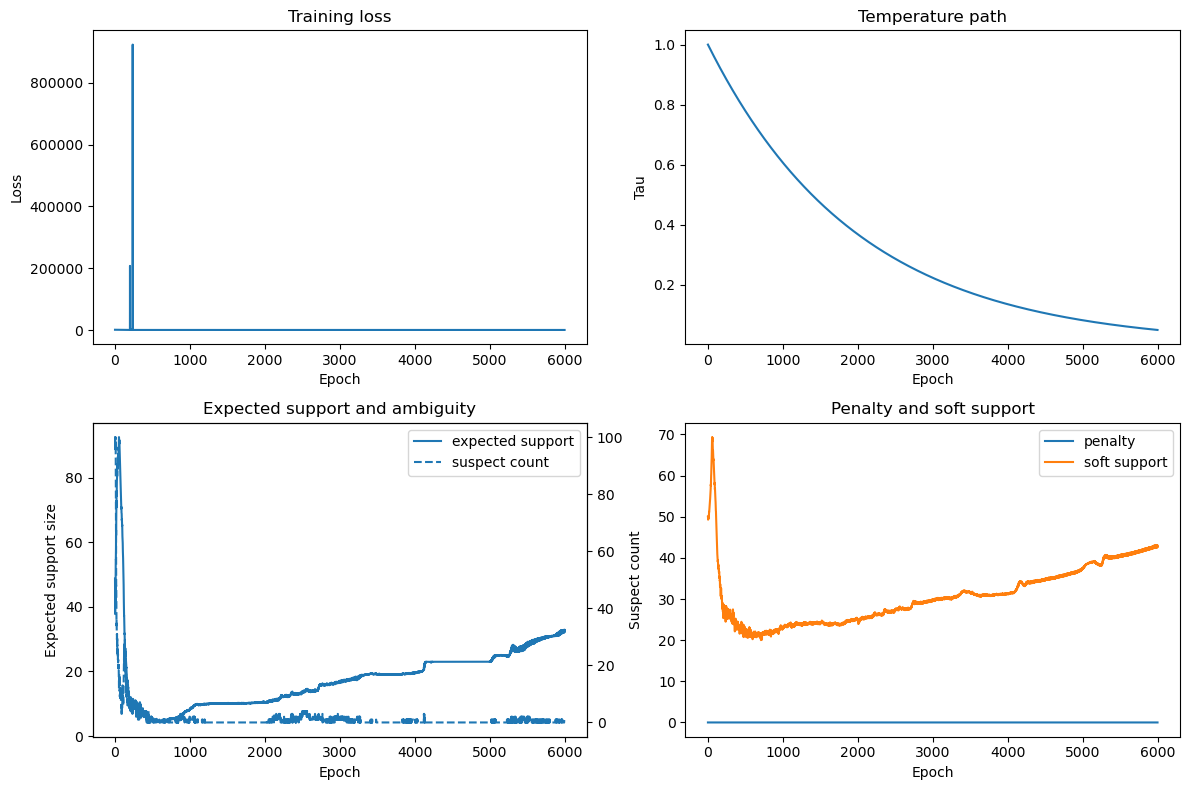

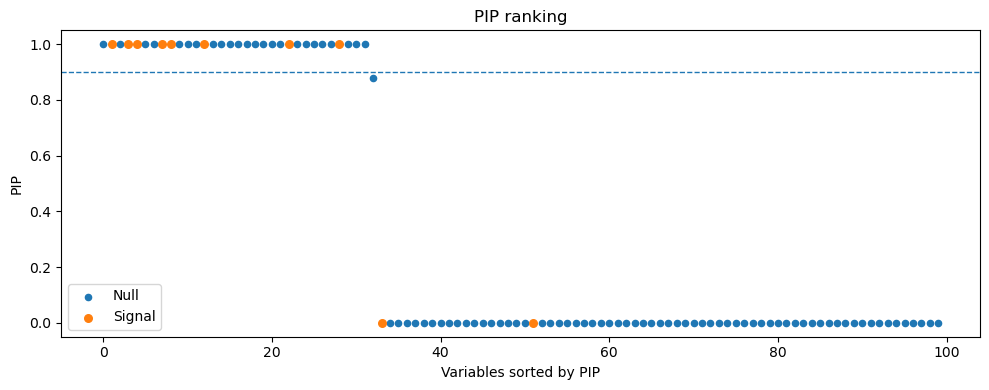

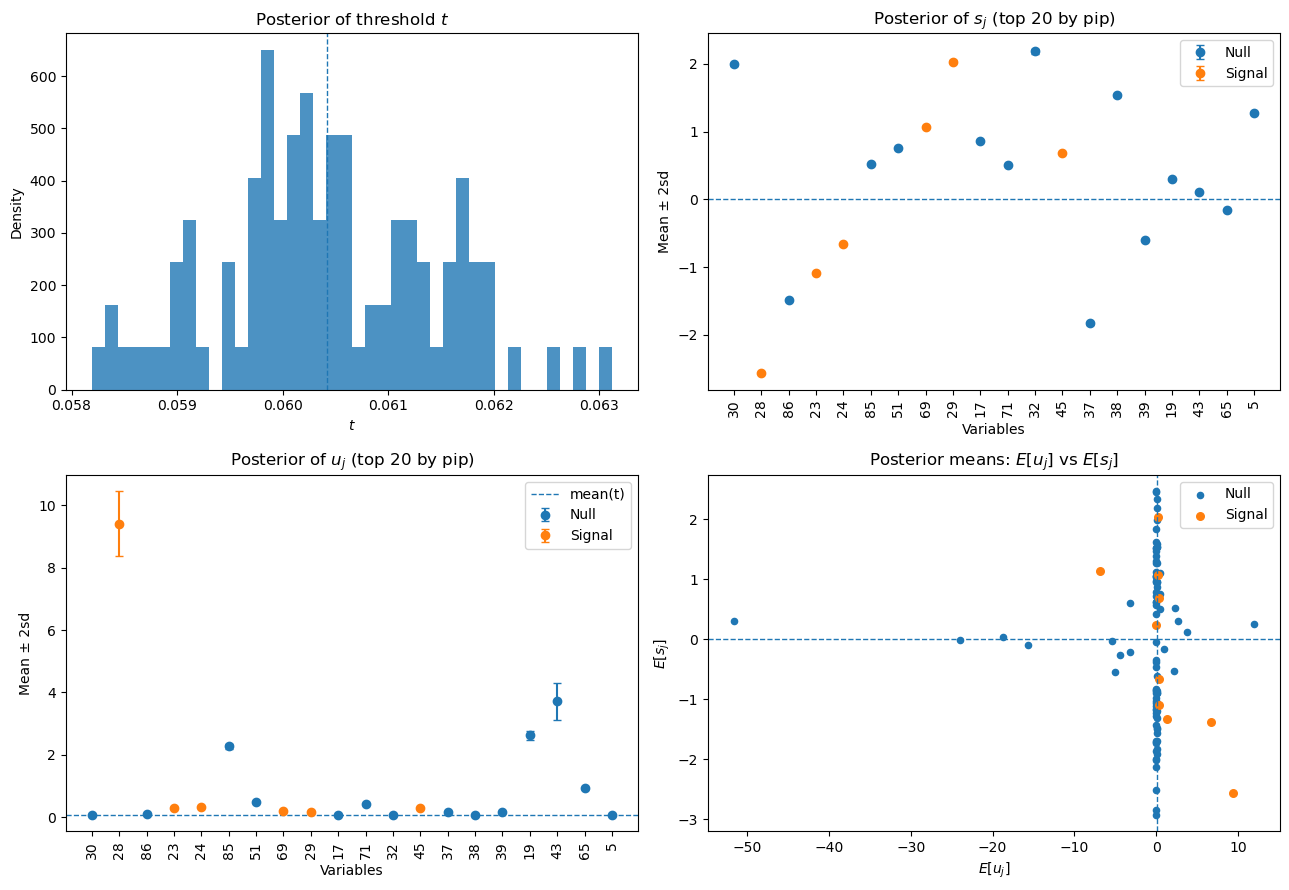

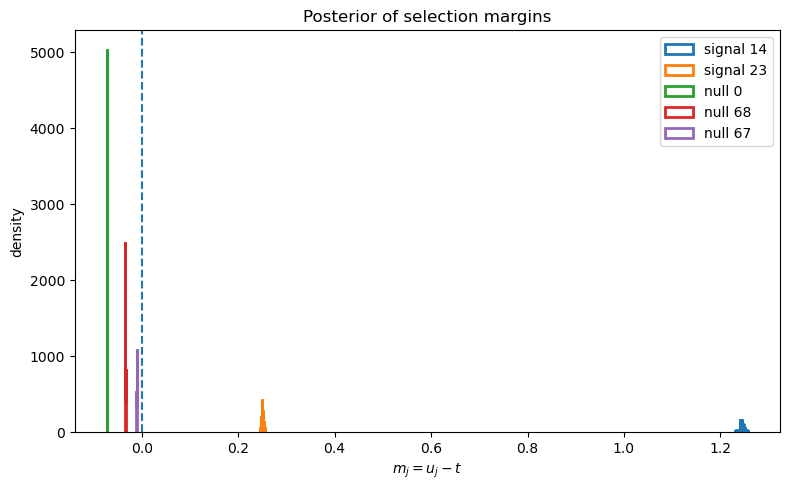

In [17]:
plot_training_overview(out_flow1); plt.show()
plot_pip_rank(out_flow1); plt.show()

plot_sut_posterior_summary(out_flow1, top_k=20, sort_by="pip")
plt.show()

plot_selection_density(out_flow1)
plt.show()

In [12]:
out_flow2 = simflow(
    seed=123,
    n=120,
    p=100,
    snr=2.5,
    true_prop=0.1,
    pip_R=100,
    pip_c=0.9,
    tau_end=0.1,
    anneal_ratio=0.8,
    K_q=16,
    K_g=16,
    hidden_units=64,
    num_hidden_layers=2,
    epochs=6000,
    num_samples=128,
    lr=5e-5,
    grad_clip=3.0,
    print_every=100,
    penalty_type="support_l1",
    penalty_weight=0.1, 
)

top_df2 = show_simflow_results(out_flow2, top_k=20, sort_by="pip")

===== Simulation info =====
{'n': 120, 'p': 100, 'n_active': 10, 'sigma2': 6.834272766113282, 'sigma': 2.614244205523516, 'active_idx': array([14, 23, 24, 28, 29, 45, 69, 74, 84, 90], dtype=int64), 'snr': 2.5}
[epoch 0001] loss=899.578186 tau=1.000000 grad_norm=387.686615 penalty=50.011761 soft_support=50.012 expected_select=48.570 suspect_number=100
[epoch 0100] loss=548.526550 tau=0.953610 grad_norm=128.181641 penalty=46.008961 soft_support=46.009 expected_select=42.980 suspect_number=4
[epoch 0200] loss=299.815033 tau=0.908935 grad_norm=739.569153 penalty=17.627871 soft_support=17.628 expected_select=4.310 suspect_number=1
[epoch 0300] loss=262.946899 tau=0.866354 grad_norm=282.328796 penalty=13.539777 soft_support=13.540 expected_select=2.570 suspect_number=0
[epoch 0400] loss=255.941467 tau=0.825767 grad_norm=169.557816 penalty=9.112166 soft_support=9.112 expected_select=2.100 suspect_number=0
[epoch 0500] loss=251.803772 tau=0.787082 grad_norm=440.293701 penalty=5.947481 soft_sup